# 0. 全局变量

In [7]:
import os
from dotenv import load_dotenv

import utils_z

In [8]:
load_dotenv()
conn = utils_z.get_conn(os.getenv("DB_NAME"), os.getenv("DB_USER"), os.getenv("DB_PASSWORD"), os.getenv("DB_HOST"), os.getenv("DB_PORT"))

# 1. Block指标

In [12]:
# 所有lod1城市对应的表名前缀
LOD1_CITIES = [
    # "hamburg", 
    "sanfrancisco",
    # "amsterdam", "dresden", "berlin", "rotterdam",
    # "luxembourg", "chicago", "boston", "washington",
    # "newyork", "portland", "tokyo", "sapporo", "osaka", "kanazawa",
    # "toronto", "vienna", "winnipeg", "zurich", "bologna",
    # "paris", "lyon", "marseille"
]

In [10]:
def add_metric_columns_lod1(conn, city):
    """为block表新增指标字段（若已存在则跳过）"""
    table = f"block.{city}_blocks"
    columns = {
        "elongation": "NUMERIC",
        "compactness": "NUMERIC",
        "lod1_building_count": "INTEGER",
        "lod1_bcr": "NUMERIC", # 建筑覆盖率
        "geom_is_valid": "BOOLEAN"
    }
    with conn.cursor() as cur:
        for col, dtype in columns.items():
            cur.execute(f"""
                ALTER TABLE {table}
                ADD COLUMN IF NOT EXISTS {col} {dtype};
            """)
    conn.commit()
    print(f"[{city}] 字段添加完成")

def compute_metrics_lod1(conn, city):
    """计算5个指标并写回block表"""
    table = f"block.{city}_blocks"
    bld_table = f"lod1.{city}_buildings_lod1"

    # Step 1: 计算几何指标（elongation, compactness, geom_is_valid）
    # 使用geography类型保证单位为米
    geom_sql = f"""
        UPDATE {table} b
        SET
            geom_is_valid = ST_IsValid(b.geom),
            compactness = CASE
                WHEN ST_Perimeter(b.geom::geography) > 0
                THEN (4 * PI() * ST_Area(b.geom::geography))
                     / (ST_Perimeter(b.geom::geography) ^ 2)
                ELSE NULL
            END,
            elongation = CASE
                WHEN ST_IsValid(b.geom)
                THEN (
                    SELECT
                        GREATEST(width, height) / NULLIF(LEAST(width, height), 0)
                    FROM (
                        SELECT
                            ST_Length(ST_LongestLine(
                                ST_OrientedEnvelope(b.geom),
                                ST_OrientedEnvelope(b.geom)
                            )::geography) AS height,
                            ST_Area(ST_OrientedEnvelope(b.geom)::geography)
                            / NULLIF(ST_Length(ST_LongestLine(
                                ST_OrientedEnvelope(b.geom),
                                ST_OrientedEnvelope(b.geom)
                            )::geography), 0) AS width
                    ) dims
                )
                ELSE NULL
            END
        WHERE b.geom IS NOT NULL;
    """

    # Step 2: 从建筑表聚合building_count和bcr
    bld_sql = f"""
        UPDATE {table} b
        SET
            lod1_building_count = agg.cnt,
            lod1_bcr = CASE
                WHEN b.area_m2 > 0
                THEN agg.total_footprint / b.area_m2
                ELSE NULL
            END
        FROM (
            SELECT
                block_id,
                COUNT(*) AS cnt,
                SUM(ST_Area(geom_2d::geography)) AS total_footprint
            FROM {bld_table}
            WHERE block_id IS NOT NULL
            GROUP BY block_id
        ) agg
        WHERE b.block_id = agg.block_id;
    """

    with conn.cursor() as cur:
        print(f"[{city}] 计算几何指标...")
        cur.execute(geom_sql)
        print(f"[{city}] 计算建筑指标...")
        cur.execute(bld_sql)
    conn.commit()
    print(f"[{city}] ✓ 完成")

In [13]:
def run_all(conn, cities):
    for city in cities:
        try:
            add_metric_columns_lod1(conn, city)
            compute_metrics_lod1(conn, city)
        except Exception as e:
            conn.rollback()
            print(f"[{city}] ✗ 错误: {e}")

run_all(conn, LOD1_CITIES)

[sanfrancisco] 字段添加完成
[sanfrancisco] 计算几何指标...
[sanfrancisco] 计算建筑指标...
[sanfrancisco] ✓ 完成


# 2. 指标分布、可视化（未进行筛除）

In [19]:
import pandas as pd

In [ ]:
city = "amsterdam"

In [101]:
table = f"block.{city}_blocks"

stats_sql = f"""
    SELECT
        COUNT(*) AS total,
        
        COUNT(*) FILTER (WHERE elongation IS NULL)          AS null_elongation,
        COUNT(*) FILTER (WHERE compactness IS NULL)         AS null_compactness,
        COUNT(*) FILTER (WHERE lod1_building_count IS NULL) AS null_building_count,
        COUNT(*) FILTER (WHERE lod1_bcr IS NULL)            AS null_bcr,
        COUNT(*) FILTER (WHERE geom_is_valid = false)       AS invalid_geom,
        
        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY elongation)::numeric, 2)  AS elongation_p50,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY elongation)::numeric, 2)  AS elongation_p95,
        ROUND(MAX(elongation)::numeric, 2)                                            AS elongation_max,
        COUNT(*) FILTER (WHERE elongation > 10)                                       AS elongation_gt10,

        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY compactness)::numeric, 3) AS compactness_p50,
        ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY compactness)::numeric, 3) AS compactness_p05,
        ROUND(MIN(compactness)::numeric, 3)                                           AS compactness_min,
        COUNT(*) FILTER (WHERE compactness < 0.1)                                     AS compactness_lt01,

        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY lod1_building_count)::numeric, 0) AS bcount_p50,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY lod1_building_count)::numeric, 0) AS bcount_p95,
        MAX(lod1_building_count)                                                               AS bcount_max,
        COUNT(*) FILTER (WHERE lod1_building_count IS NULL OR lod1_building_count = 0)        AS bcount_zero,
        COUNT(*) FILTER (WHERE lod1_building_count = 1)                                        AS bcount_one,

        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY lod1_bcr)::numeric, 3) AS bcr_p50,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY lod1_bcr)::numeric, 3) AS bcr_p95,
        ROUND(MAX(lod1_bcr)::numeric, 3)                                           AS bcr_max,
        COUNT(*) FILTER (WHERE lod1_bcr > 1)                                       AS bcr_gt1,
        COUNT(*) FILTER (WHERE lod1_bcr < 0.01)                                    AS bcr_lt001,

        ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p50,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p95,
        ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p99,
        ROUND(MIN(area_m2)::numeric, 0)                                           AS area_min,
        ROUND(MAX(area_m2)::numeric, 0)                                           AS area_max,
        COUNT(*) FILTER (WHERE area_m2 > 200000)                                  AS area_gt200k

    FROM {table};
"""

stats = utils_z.run_sql(stats_sql, fetch=True, conn=conn)[0]
labels = [
    "total", "null_elongation", "null_compactness", "null_building_count",
    "null_bcr", "invalid_geom",
    "elongation_p50", "elongation_p95", "elongation_max", "elongation_gt10",
    "compactness_p50", "compactness_p05", "compactness_min", "compactness_lt01",
    "bcount_p50", "bcount_p95", "bcount_max", "bcount_zero", "bcount_one",
    "bcr_p50", "bcr_p95", "bcr_max", "bcr_gt1", "bcr_lt001",
    "area_p50", "area_p95", "area_p99", "area_min", "area_max", "area_gt200k"
]
s = dict(zip(labels, stats))

print(f"\n{'='*50}")
print(f"城市: {city.upper()}    总block数: {s['total']}")
print(f"{'='*50}")
print(f"[几何有效性]  无效geom: {s['invalid_geom']}")
print(f"[面积]        中位数: {s['area_p50']:.0f}㎡  P95: {s['area_p95']:.0f}㎡  P99: {s['area_p99']:.0f}㎡  最小: {s['area_min']:.0f}㎡  最大: {s['area_max']:.0f}㎡  >20公顷: {s['area_gt200k']}")
print(f"[elongation]  中位数: {s['elongation_p50']}  P95: {s['elongation_p95']}  最大: {s['elongation_max']}  >10的数量: {s['elongation_gt10']}")
print(f"[compactness] 中位数: {s['compactness_p50']}  P05: {s['compactness_p05']}  最小: {s['compactness_min']}  <0.1的数量: {s['compactness_lt01']}")
print(f"[建筑数量]    中位数: {s['bcount_p50']}  P95: {s['bcount_p95']}  最大: {s['bcount_max']}  0栋: {s['bcount_zero']}  1栋: {s['bcount_one']}")
print(f"[BCR]         中位数: {s['bcr_p50']}  P95: {s['bcr_p95']}  最大: {s['bcr_max']}  >1: {s['bcr_gt1']}  <0.01: {s['bcr_lt001']}")
print(f"[空值]  elongation: {s['null_elongation']}  compactness: {s['null_compactness']}  building_count: {s['null_building_count']}  bcr: {s['null_bcr']}")


城市: AMSTERDAM    总block数: 4998
[几何有效性]  无效geom: 0
[面积]        中位数: 7416㎡  P95: 73562㎡  P99: 370217㎡  最小: 1000㎡  最大: 6675873㎡  >20公顷: 111
[elongation]  中位数: 3.13  P95: 17.17  最大: 159.45  >10的数量: 566
[compactness] 中位数: 0.567  P05: 0.101  最小: 0.011  <0.1的数量: 244
[建筑数量]    中位数: 32  P95: 142  最大: 1021  0栋: 1880  1栋: 190
[BCR]         中位数: 0.312  P95: 0.615  最大: 2.722  >1: 16  <0.01: 86
[空值]  elongation: 0  compactness: 0  building_count: 1880  bcr: 1880


In [102]:
# 直接排除没有建筑的block
data_sql = f"""
    SELECT
        elongation,
        compactness,
        lod1_building_count AS building_count,
        lod1_bcr AS bcr,
        area_m2
    FROM {table}
    WHERE elongation IS NOT NULL
      AND compactness IS NOT NULL
      AND lod1_building_count IS NOT NULL
      AND lod1_bcr IS NOT NULL
      AND lod1_building_count >= 1 
      AND elongation < 50
      AND lod1_bcr < 2
"""
df = pd.read_sql(data_sql, conn)
print(f"有建筑的block数: {len(df)} 条")

有建筑的block数: 3115 条


C:\Users\94017\AppData\Local\Temp\ipykernel_9364\3854433932.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(data_sql, conn)


In [22]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt

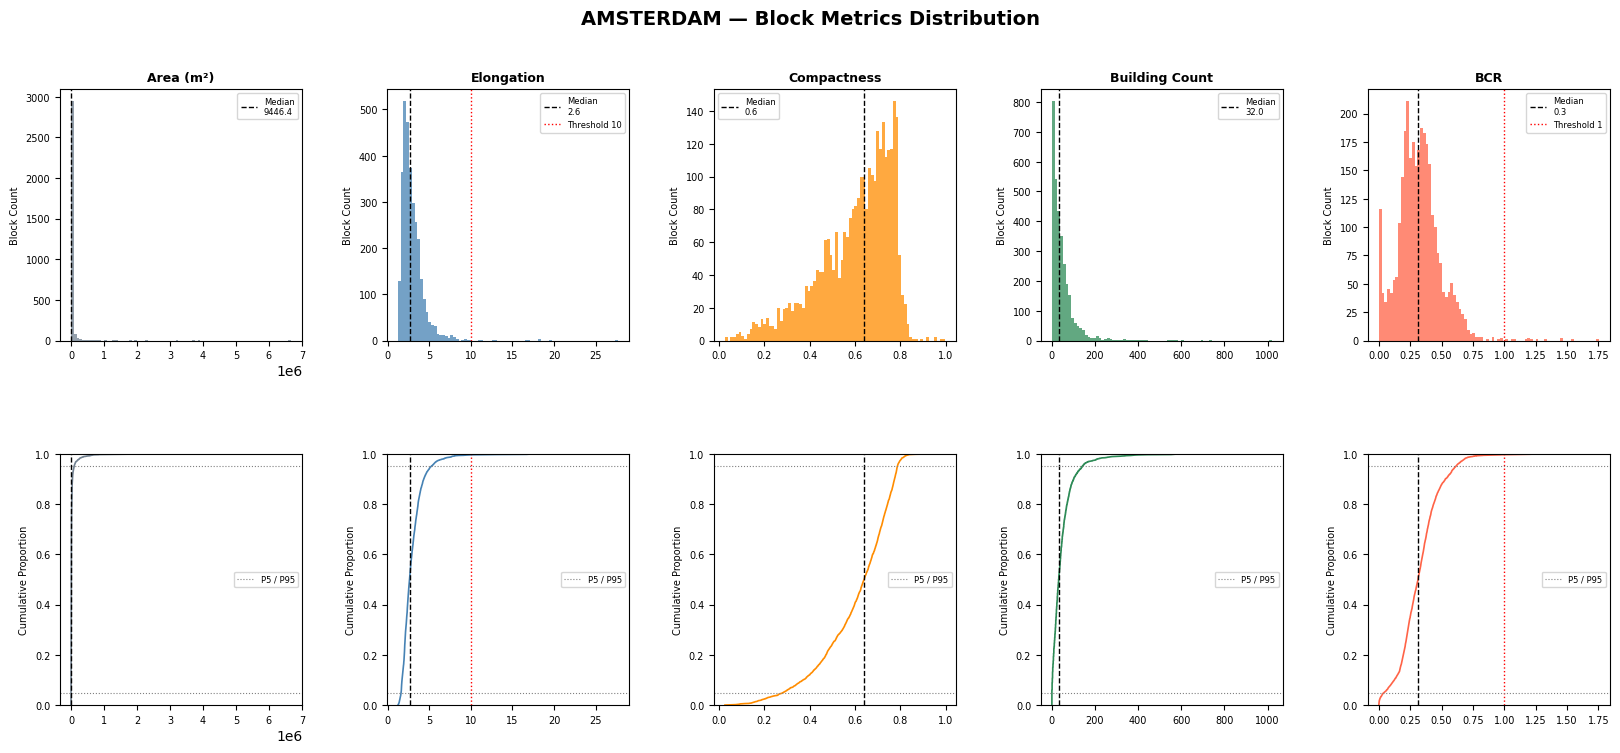

In [103]:
metrics = [
    ("area_m2",        "Area (m²)",          None,  "slategray"),
    ("elongation",     "Elongation",         10,    "steelblue"),
    ("compactness",    "Compactness",        None,  "darkorange"),
    ("building_count", "Building Count",     None,  "seagreen"),
    ("bcr",            "BCR",                1,     "tomato"),
]

fig = plt.figure(figsize=(20, 8))
fig.suptitle(f"{city.upper()} — Block Metrics Distribution", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 5, hspace=0.45, wspace=0.35)

for col_i, (col, title, threshold, color) in enumerate(metrics):
    data = df[col].dropna()
    # use_log = col in ("area_m2", "building_count")

    # Top: Histogram
    ax_hist = fig.add_subplot(gs[0, col_i])
    ax_hist.hist(data, bins=80, color=color, alpha=0.75, edgecolor='none')
    # if use_log:
    #     ax_hist.set_xscale('log')
    median = data.median()
    ax_hist.axvline(median, color='black', linestyle='--', linewidth=1,
                    label=f'Median\n{median:.1f}')
    if threshold:
        ax_hist.axvline(threshold, color='red', linestyle=':', linewidth=1,
                        label=f'Threshold {threshold}')
    ax_hist.set_title(title, fontsize=9, fontweight='bold')
    ax_hist.set_ylabel("Block Count", fontsize=7)
    ax_hist.legend(fontsize=6)
    ax_hist.tick_params(labelsize=7)

    # Bottom: ECDF
    ax_ecdf = fig.add_subplot(gs[1, col_i])
    sorted_data = np.sort(data)
    ecdf_y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax_ecdf.plot(sorted_data, ecdf_y, color=color, linewidth=1.2)
    # if use_log:
    #     ax_ecdf.set_xscale('log')
    ax_ecdf.axvline(median, color='black', linestyle='--', linewidth=1)
    if threshold:
        ax_ecdf.axvline(threshold, color='red', linestyle=':', linewidth=1)
    ax_ecdf.set_ylabel("Cumulative Proportion", fontsize=7)
    ax_ecdf.set_ylim(0, 1)
    ax_ecdf.axhline(0.95, color='gray', linestyle=':', linewidth=0.8, label='P5 / P95')
    ax_ecdf.axhline(0.05, color='gray', linestyle=':', linewidth=0.8)
    ax_ecdf.legend(fontsize=6)
    ax_ecdf.tick_params(labelsize=7)

# plt.savefig(f"{city}_block_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. 硬性阈值配合Isolation Forest进行数据筛除的尝试

## 3.1 isolation forest

In [24]:
from sklearn.ensemble import IsolationForest
import pandas as pd

In [25]:
city = "amsterdam"
table = f"block.{city}_blocks"

# Step 1: 拉取特征数据（仅有建筑的block）
data_sql = f"""
    SELECT block_id, area_m2, elongation, compactness, lod1_building_count, lod1_bcr, geom_is_valid
    FROM {table}
    WHERE lod1_building_count >= 1
      AND lod1_bcr <= 1          -- 硬阈值: BCR>1直接排除
      AND elongation IS NOT NULL
      AND compactness IS NOT NULL
      AND lod1_bcr IS NOT NULL
      AND geom_is_valid = true   -- 仅分析几何有效的block
"""
df = pd.read_sql(data_sql, conn)
print(f"输入样本数: {len(df)}")

输入样本数: 3102


C:\Users\94017\AppData\Local\Temp\ipykernel_9364\460820767.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(data_sql, conn)


In [26]:
# Step 2: 隔离森林
features = ["area_m2", "elongation", "compactness", "lod1_building_count", "lod1_bcr"]
X = df[features]

clf = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # 预期5%为异常，可以调整
    random_state=42
)
df["if_label"] = clf.fit_predict(X)        # -1=异常, 1=正常
df["if_score"] = clf.decision_function(X)  # 越负越异常

normal = df[df["if_label"] == 1]
anomaly = df[df["if_label"] == -1]
print(f"正常block: {len(normal)}  异常block: {len(anomaly)}  异常比例: {len(anomaly)/len(df):.1%}")

# 随机最多30个异常block的ID
anomaly_ids = anomaly['block_id'].sample(n=min(30, len(anomaly)), random_state=42).tolist()
print(f"异常block_id示例（最多30个）:\n{anomaly_ids}")

正常block: 2946  异常block: 156  异常比例: 5.0%
异常block_id示例（最多30个）:
['NL_AM_003000', 'NL_AM_002325', 'NL_AM_002768', 'NL_AM_002679', 'NL_AM_003572', 'NL_AM_000917', 'NL_AM_002956', 'NL_AM_004115', 'NL_AM_002940', 'NL_AM_004231', 'NL_AM_000546', 'NL_AM_002889', 'NL_AM_000461', 'NL_AM_003881', 'NL_AM_000708', 'NL_AM_000919', 'NL_AM_003806', 'NL_AM_003649', 'NL_AM_004789', 'NL_AM_002714', 'NL_AM_003071', 'NL_AM_000538', 'NL_AM_000441', 'NL_AM_000392', 'NL_AM_000966', 'NL_AM_003310', 'NL_AM_002280', 'NL_AM_001572', 'NL_AM_001530', 'NL_AM_000039']


In [27]:
# Step 3: 查看被标记为异常的block的特征分布
print("\n--- 异常block特征摘要 ---")
print(anomaly[features].describe().round(2))


--- 异常block特征摘要 ---
          area_m2  elongation  compactness  lod1_building_count  lod1_bcr
count      156.00      156.00       156.00               156.00    156.00
mean    366510.86        4.98         0.33               163.54      0.21
std     775405.42        4.12         0.20               185.02      0.25
min       1253.74        1.33         0.03                 1.00      0.00
25%      24853.51        2.14         0.17                 6.75      0.03
50%     132351.61        3.25         0.28               114.50      0.10
75%     375504.21        6.99         0.45               230.50      0.26
max    6675873.08       19.46         0.90              1021.00      0.98


## 3.2 PCA降维后查看样本分布

In [28]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

In [30]:
labels = np.array(df["if_label"].map({1: "Normal", -1: "Anomaly"}))

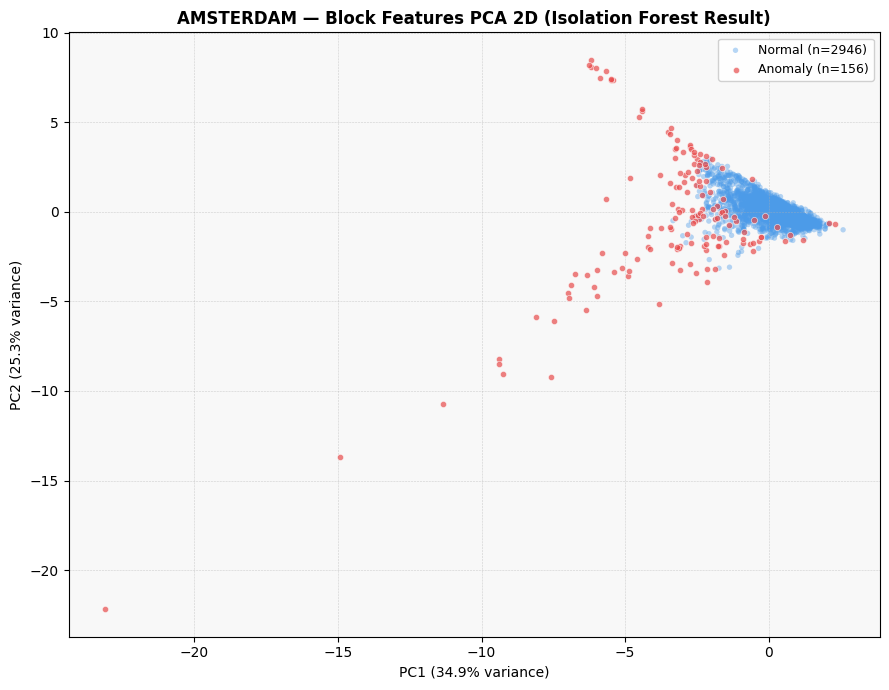

In [93]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor("#f8f8f8")
fig.patch.set_facecolor("white")

# 先画正常点
mask_normal = labels == "Normal"
ax.scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
           c="#4C9BE8", label=f"Normal (n={mask_normal.sum()})",
           alpha=0.4, s=15, edgecolors='none', zorder=1)

# 异常点加描边增加对比度
mask_anomaly = labels == "Anomaly"
ax.scatter(X_pca[mask_anomaly, 0], X_pca[mask_anomaly, 1],
           c="#E84C4C", label=f"Anomaly (n={mask_anomaly.sum()})",
           alpha=0.7, s=20, edgecolors='white', linewidths=0.5, zorder=2)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=10)
ax.set_title(f"{city.upper()} — Block Features PCA 2D (Isolation Forest Result)", fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

plt.tight_layout()

savefig_path = fr"E:\AAA_Study\202603_PhDDissertation\图片\block isolation forest result\{city}_lod1_if_pca_2d.png"
plt.savefig(savefig_path, dpi=300, bbox_inches='tight')
plt.show()

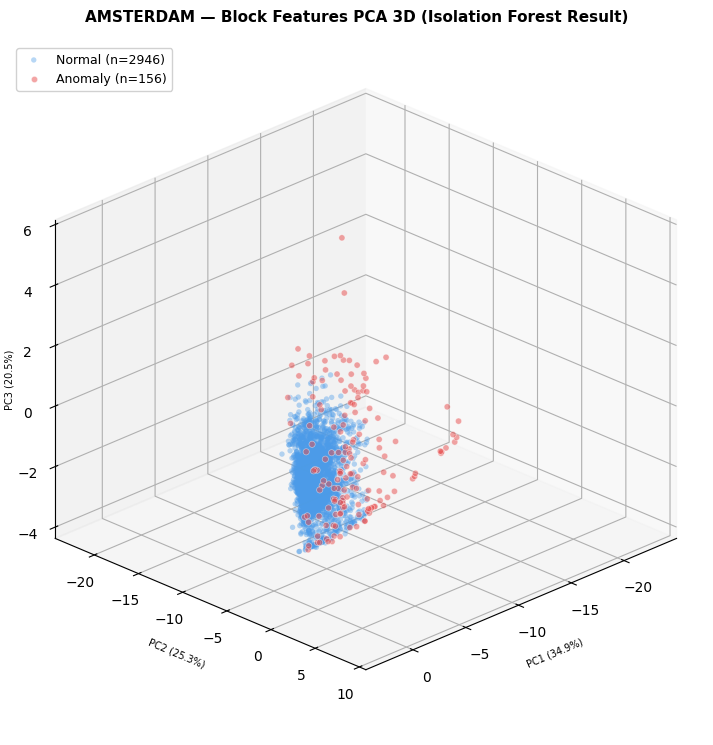

In [92]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(11, 9))
# ax = fig.add_subplot(111, projection='3d')
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')
fig.patch.set_facecolor("white")

mask_normal = labels == "Normal"
mask_anomaly = labels == "Anomaly"

ax.scatter(X_pca3[mask_normal, 0], X_pca3[mask_normal, 1], X_pca3[mask_normal, 2],
           c="#4C9BE8", label=f"Normal (n={mask_normal.sum()})",
           alpha=0.4, s=15, edgecolors='none', zorder=1)

ax.scatter(X_pca3[mask_anomaly, 0], X_pca3[mask_anomaly, 1], X_pca3[mask_anomaly, 2],
           c="#E84C4C", label=f"Anomaly (n={mask_anomaly.sum()})",
           alpha=0.5, s=20, edgecolors='white', linewidths=0.5, zorder=2)

# --- 【修改点 1】微调 labelpad --------------------------------------------------
# 3D 图中 labelpad 过大会把标签推远导致切边，适当缩小（甚至可以尝试 0 或负数如 -2）
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})", fontsize=7, labelpad=7)
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})", fontsize=7, labelpad=7)
ax.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2]:.1%})", fontsize=7, labelpad=-2) # Z轴标签靠拢

ax.set_title(f"{city.upper()} — Block Features PCA 3D (Isolation Forest Result)",
             fontsize=11, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.9, loc='upper left')

# 调整视角
ax.view_init(elev=25, azim=45)
ax.set_box_aspect((1, 1, 0.8))

# ax.set_position([0.15, 0.0, 1, 1])
savefig_path = fr"E:\AAA_Study\202603_PhDDissertation\图片\block isolation forest result\{city}_lod1_if_pca_3d.png"
plt.savefig(savefig_path, dpi=300, bbox_inches='tight')
plt.show()

## 3.3 给block表更新标记字段

In [85]:
from psycopg2.extras import execute_values

In [86]:
table = f"block.{city}_blocks"

# 准备更新数据
update_data = []
for _, row in df.iterrows():
    is_valid = bool(row["if_label"] == 1)
    reason = None if is_valid else "isolation_forest"
    update_data.append((is_valid, reason, row["block_id"]))

# 硬阈值排除的单独标记（BCR>1，已在拉数据时过滤，这里补回来）
hard_exclude_sql = f"""
    UPDATE {table}
    SET is_valid_lod1 = false,
        exclude_reason_lod1 = 'bcr>1'
    WHERE lod1_bcr > 1;
"""

# 无建筑的block
no_bld_sql = f"""
    UPDATE {table}
    SET is_valid_lod1 = false,
        exclude_reason_lod1 = 'no_buildings'
    WHERE lod1_building_count IS NULL OR lod1_building_count = 0;
"""

with conn.cursor() as cur:
    # 先加字段
    cur.execute(f"""
        ALTER TABLE {table}
        ADD COLUMN IF NOT EXISTS is_valid_lod1 BOOLEAN,
        ADD COLUMN IF NOT EXISTS exclude_reason_lod1 TEXT;
    """)
    # 写回隔离森林结果
    execute_values(cur, f"""
        UPDATE {table} AS b
        SET is_valid_lod1 = v.is_valid,
            exclude_reason_lod1 = v.reason
        FROM (VALUES %s) AS v(is_valid, reason, block_id)
        WHERE b.block_id = v.block_id
    """, update_data)
    # 硬阈值覆盖
    cur.execute(hard_exclude_sql)
    cur.execute(no_bld_sql)

conn.commit()

# 验证
result = utils_z.run_sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(*) FILTER (WHERE is_valid_lod1 = true) AS valid,
        COUNT(*) FILTER (WHERE is_valid_lod1 = false) AS excluded,
        COUNT(*) FILTER (WHERE exclude_reason_lod1 = 'no_buildings') AS excl_no_bld,
        COUNT(*) FILTER (WHERE exclude_reason_lod1 = 'bcr>1') AS excl_bcr,
        COUNT(*) FILTER (WHERE exclude_reason_lod1 = 'isolation_forest') AS excl_if
    FROM {table};
""", fetch=True, conn=conn)[0]

print(f"总计: {result[0]}  有效: {result[1]}  排除: {result[2]}")
print(f"  排除原因 - 无建筑: {result[3]}  BCR>1: {result[4]}  隔离森林: {result[5]}")

总计: 4998  有效: 2946  排除: 2052
  排除原因 - 无建筑: 1880  BCR>1: 16  隔离森林: 156


# 4. 对比一下筛选前后的指标分布

In [98]:
table = f"block.{city}_blocks"

def print_stats(conn, table, label, where_clause):
    stats_sql = f"""
        SELECT
            COUNT(*) AS total,
            
            COUNT(*) FILTER (WHERE elongation IS NULL)          AS null_elongation,
            COUNT(*) FILTER (WHERE compactness IS NULL)         AS null_compactness,
            COUNT(*) FILTER (WHERE lod1_building_count IS NULL) AS null_building_count,
            COUNT(*) FILTER (WHERE lod1_bcr IS NULL)            AS null_bcr,
            COUNT(*) FILTER (WHERE geom_is_valid = false)       AS invalid_geom,
            
            ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY elongation)::numeric, 2)  AS elongation_p50,
            ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY elongation)::numeric, 2)  AS elongation_p95,
            ROUND(MAX(elongation)::numeric, 2)                                            AS elongation_max,
            COUNT(*) FILTER (WHERE elongation > 10)                                       AS elongation_gt10,

            ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY compactness)::numeric, 3) AS compactness_p50,
            ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY compactness)::numeric, 3) AS compactness_p05,
            ROUND(MIN(compactness)::numeric, 3)                                           AS compactness_min,
            COUNT(*) FILTER (WHERE compactness < 0.1)                                     AS compactness_lt01,

            ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY lod1_building_count)::numeric, 0) AS bcount_p50,
            ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY lod1_building_count)::numeric, 0) AS bcount_p95,
            MAX(lod1_building_count)                                                               AS bcount_max,
            COUNT(*) FILTER (WHERE lod1_building_count IS NULL OR lod1_building_count = 0)        AS bcount_zero,
            COUNT(*) FILTER (WHERE lod1_building_count = 1)                                        AS bcount_one,

            ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY lod1_bcr)::numeric, 3) AS bcr_p50,
            ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY lod1_bcr)::numeric, 3) AS bcr_p95,
            ROUND(MAX(lod1_bcr)::numeric, 3)                                           AS bcr_max,
            COUNT(*) FILTER (WHERE lod1_bcr > 1)                                       AS bcr_gt1,
            COUNT(*) FILTER (WHERE lod1_bcr < 0.01)                                    AS bcr_lt001,

            ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p50,
            ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p95,
            ROUND(PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY area_m2)::numeric, 0) AS area_p99,
            ROUND(MIN(area_m2)::numeric, 0)                                           AS area_min,
            ROUND(MAX(area_m2)::numeric, 0)                                           AS area_max,
            COUNT(*) FILTER (WHERE area_m2 > 200000)                                  AS area_gt200k

        FROM {table}
        WHERE {where_clause};
    """
    stats = utils_z.run_sql(stats_sql, fetch=True, conn=conn)[0]
    labels_list = [
        "total", "null_elongation", "null_compactness", "null_building_count",
        "null_bcr", "invalid_geom",
        "elongation_p50", "elongation_p95", "elongation_max", "elongation_gt10",
        "compactness_p50", "compactness_p05", "compactness_min", "compactness_lt01",
        "bcount_p50", "bcount_p95", "bcount_max", "bcount_zero", "bcount_one",
        "bcr_p50", "bcr_p95", "bcr_max", "bcr_gt1", "bcr_lt001",
        "area_p50", "area_p95", "area_p99", "area_min", "area_max", "area_gt200k"
    ]
    s = dict(zip(labels_list, stats))

    print(f"\n{'='*50}")
    print(f"[{label}]  城市: {city.upper()}    总block数: {s['total']}")
    print(f"{'='*50}")
    print(f"[几何有效性]  无效geom: {s['invalid_geom']}")
    print(f"[面积]        中位数: {s['area_p50']:.0f}㎡  P95: {s['area_p95']:.0f}㎡  P99: {s['area_p99']:.0f}㎡  最小: {s['area_min']:.0f}㎡  最大: {s['area_max']:.0f}㎡  >20公顷: {s['area_gt200k']}")
    print(f"[elongation]  中位数: {s['elongation_p50']}  P95: {s['elongation_p95']}  最大: {s['elongation_max']}  >10的数量: {s['elongation_gt10']}")
    print(f"[compactness] 中位数: {s['compactness_p50']}  P05: {s['compactness_p05']}  最小: {s['compactness_min']}  <0.1的数量: {s['compactness_lt01']}")
    print(f"[建筑数量]    中位数: {s['bcount_p50']}  P95: {s['bcount_p95']}  最大: {s['bcount_max']}  0栋: {s['bcount_zero']}  1栋: {s['bcount_one']}")
    print(f"[BCR]         中位数: {s['bcr_p50']}  P95: {s['bcr_p95']}  最大: {s['bcr_max']}  >1: {s['bcr_gt1']}  <0.01: {s['bcr_lt001']}")
    print(f"[空值]  elongation: {s['null_elongation']}  compactness: {s['null_compactness']}  building_count: {s['null_building_count']}  bcr: {s['null_bcr']}")

# 分别打印原始和筛除后
print_stats(conn, table, "ALL BLOCKS (原始)", "1=1")
print_stats(conn, table, "VALID BLOCKS (筛除后)", "is_valid_lod1 = true")


[ALL BLOCKS (原始)]  城市: AMSTERDAM    总block数: 4998
[几何有效性]  无效geom: 0
[面积]        中位数: 7416㎡  P95: 73562㎡  P99: 370217㎡  最小: 1000㎡  最大: 6675873㎡  >20公顷: 111
[elongation]  中位数: 3.13  P95: 17.17  最大: 159.45  >10的数量: 566
[compactness] 中位数: 0.567  P05: 0.101  最小: 0.011  <0.1的数量: 244
[建筑数量]    中位数: 32  P95: 142  最大: 1021  0栋: 1880  1栋: 190
[BCR]         中位数: 0.312  P95: 0.615  最大: 2.722  >1: 16  <0.01: 86
[空值]  elongation: 0  compactness: 0  building_count: 1880  bcr: 1880

[VALID BLOCKS (筛除后)]  城市: AMSTERDAM    总block数: 2946
[几何有效性]  无效geom: 0
[面积]        中位数: 9147㎡  P95: 55662㎡  P99: 139885㎡  最小: 1023㎡  最大: 284963㎡  >20公顷: 14
[elongation]  中位数: 2.60  P95: 4.89  最大: 8.03  >10的数量: 0
[compactness] 中位数: 0.649  P05: 0.338  最小: 0.093  <0.1的数量: 1
[建筑数量]    中位数: 32  P95: 120  最大: 367  0栋: 0  1栋: 155
[BCR]         中位数: 0.316  P95: 0.601  最大: 0.901  >1: 0  <0.01: 59
[空值]  elongation: 0  compactness: 0  building_count: 0  bcr: 0


In [106]:
def fetch_plot_data(conn, table, where_clause):
    data_sql = f"""
        SELECT elongation, compactness, lod1_building_count AS building_count, lod1_bcr AS bcr, area_m2
        FROM {table}
        WHERE elongation IS NOT NULL
          AND compactness IS NOT NULL
          AND lod1_building_count IS NOT NULL
          AND lod1_bcr IS NOT NULL
          AND elongation < 50
          AND lod1_bcr < 2
          AND {where_clause}
    """
    return pd.read_sql(data_sql, conn)

df_all   = fetch_plot_data(conn, table, "1=1")
df_valid = fetch_plot_data(conn, table, "is_valid_lod1 = true")
print(f"原始: {len(df_all)} 条    筛除后: {len(df_valid)} 条")
# df_all   = fetch_plot_data(conn, table, "lod1_building_count >= 1")
# df_valid = fetch_plot_data(conn, table, "is_valid_lod1 = true")
# print(f"有建筑block(原始): {len(df_all)} 条    筛除后: {len(df_valid)} 条")

原始: 3115 条    筛除后: 2946 条


C:\Users\94017\AppData\Local\Temp\ipykernel_9364\3942923827.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(data_sql, conn)


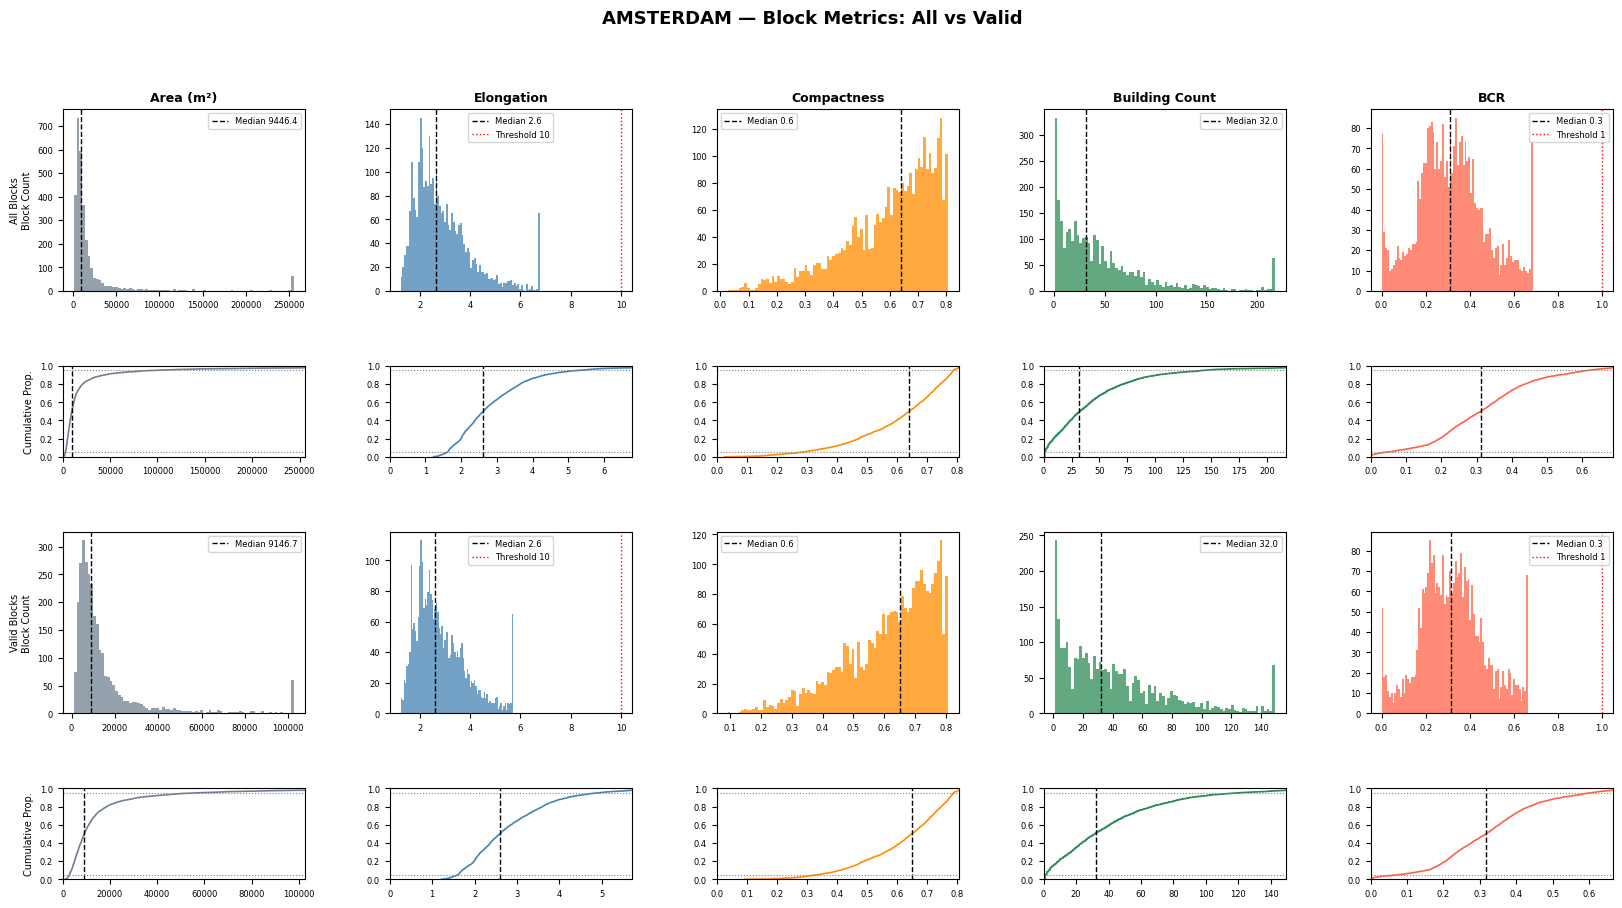

In [107]:
metrics = [
    ("area_m2",        "Area (m²)",     None, "slategray"),
    ("elongation",     "Elongation",    10,   "steelblue"),
    ("compactness",    "Compactness",   None, "darkorange"),
    ("building_count", "Building Count",None, "seagreen"),
    ("bcr",            "BCR",           1,    "tomato"),
]

datasets = [
    (df_all,   "All Blocks"),
    (df_valid, "Valid Blocks"),
]

fig = plt.figure(figsize=(20, 10))
fig.suptitle(f"{city.upper()} — Block Metrics: All vs Valid", fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(4, 5, hspace=0.55, wspace=0.35,
                       height_ratios=[2, 1, 2, 1])

for row_group, (df_plot, group_label) in enumerate(datasets):
    hist_row = row_group * 2
    ecdf_row = row_group * 2 + 1

    for col_i, (col, title, threshold, color) in enumerate(metrics):
        data = df_plot[col].dropna()
        clip_max = data.quantile(0.98)

        # 直方图
        ax_hist = fig.add_subplot(gs[hist_row, col_i])
        ax_hist.hist(data.clip(upper=clip_max), bins=80,
                     color=color, alpha=0.75, edgecolor='none')
        median = data.median()
        ax_hist.axvline(median, color='black', linestyle='--', linewidth=1,
                        label=f'Median {median:.1f}')
        if threshold:
            ax_hist.axvline(threshold, color='red', linestyle=':', linewidth=1,
                            label=f'Threshold {threshold}')
        if col_i == 0:
            ax_hist.set_ylabel(f"{group_label}\nBlock Count", fontsize=7)
        ax_hist.set_title(title if row_group == 0 else "", fontsize=9, fontweight='bold')
        ax_hist.legend(fontsize=6)
        ax_hist.tick_params(labelsize=6)

        # ECDF
        ax_ecdf = fig.add_subplot(gs[ecdf_row, col_i])
        sorted_data = np.sort(data)
        ecdf_y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax_ecdf.plot(sorted_data, ecdf_y, color=color, linewidth=1.2)
        ax_ecdf.set_xlim(left=0, right=float(clip_max))
        ax_ecdf.axvline(median, color='black', linestyle='--', linewidth=1)
        if threshold:
            ax_ecdf.axvline(threshold, color='red', linestyle=':', linewidth=1)
        ax_ecdf.axhline(0.95, color='gray', linestyle=':', linewidth=0.8)
        ax_ecdf.axhline(0.05, color='gray', linestyle=':', linewidth=0.8)
        if col_i == 0:
            ax_ecdf.set_ylabel("Cumulative Prop.", fontsize=7)
        ax_ecdf.set_ylim(0, 1)
        ax_ecdf.tick_params(labelsize=6)

plt.savefig(f"{city}_block_metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()